In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

file_path = "/home/hadis/custom_vector/buildParticleOriented/buildVS/nov25_new/N_particle_PosMD.dat"
particle_type = "oriented"

skip_rows = 30
frame_size = 800
particle_radius = 10
output_file = 'oriented_nov24_phiConst1.mp4'

freedom_d = 2 if particle_type == "dot" else 3

positions = []
with open(file_path, 'r') as file:
    for i, line in enumerate(file):
        if i % skip_rows == 0:
            data = line.strip().split()
            data = list(map(float, data[1:]))
            positions.append(data)
positions = np.array(positions)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, 10.0, (frame_size, frame_size))

scale = frame_size / 20
offset = 0

def map_to_frame(x, y):
    return int(x * scale + offset), int(y * scale + offset)

for i, frame_data in enumerate(positions):
    frame = np.ones((frame_size, frame_size, 3), dtype=np.uint8) * 255

    for j in range(0, len(frame_data), freedom_d):
        x, y = frame_data[j], frame_data[j + 1]
        cx, cy = map_to_frame(x, y)
        color = (120, 120, 120)
        cv2.circle(frame, (cx, cy), particle_radius, color, -1)

        if freedom_d == 3:
            phi = frame_data[j + 2]
            line_length = 10
            end_x = int(cx + line_length * np.cos(np.radians(phi)))
            end_y = int(cy + line_length * np.sin(np.radians(phi)))
            cv2.line(frame, (cx, cy), (end_x, end_y), (0, 0, 255), 2)

    out.write(frame)

    if i % 50 == 0:
        print(f"Processing frame {i}/{len(positions)}")

out.release()
print("Video saved as", output_file)

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Particle Movement at Last Frame")
plt.show()


Processing frame 0/40000
Processing frame 50/40000
Processing frame 100/40000
Processing frame 150/40000
Processing frame 200/40000
Processing frame 250/40000
Processing frame 300/40000
Processing frame 350/40000
Processing frame 400/40000
Processing frame 450/40000
Processing frame 500/40000
Processing frame 550/40000
Processing frame 600/40000
Processing frame 650/40000
Processing frame 700/40000
Processing frame 750/40000
Processing frame 800/40000
Processing frame 850/40000
Processing frame 900/40000
Processing frame 950/40000
Processing frame 1000/40000
Processing frame 1050/40000
Processing frame 1100/40000
Processing frame 1150/40000
Processing frame 1200/40000
Processing frame 1250/40000
Processing frame 1300/40000
Processing frame 1350/40000
Processing frame 1400/40000
Processing frame 1450/40000
Processing frame 1500/40000
Processing frame 1550/40000
Processing frame 1600/40000
Processing frame 1650/40000
Processing frame 1700/40000
Processing frame 1750/40000
Processing fram

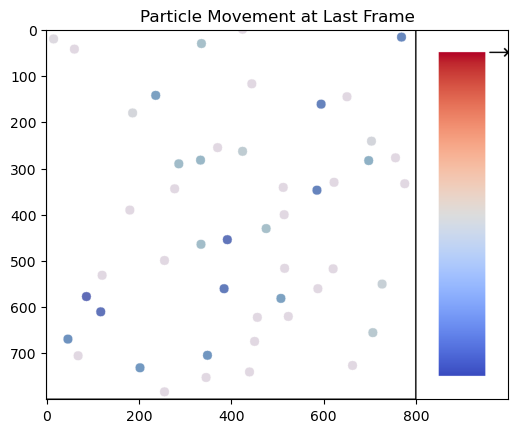

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm

file_path = "/home/hadis/custom_vector/buildParticleOriented/buildVS/nov27/N_particle_PosMD.dat"
particle_type = "oriented"

skip_rows = 5
frame_size = 800
particle_radius = 10
output_file = 'oriented_nov27_skip5.mp4'

freedom_d = 2 if particle_type == "dot" else 3

positions = []
with open(file_path, 'r') as file:
    for i, line in enumerate(file):
        if i % skip_rows == 0:
            data = line.strip().split()
            data = list(map(float, data[1:]))
            positions.append(data)
positions = np.array(positions)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, 10.0, (frame_size + 200, frame_size))

scale = frame_size / 20
offset = 0

def map_to_frame(x, y):
    return int(x * scale + offset), int(y * scale + offset)

def phi_to_color(phi):
    norm_phi = phi / (2 * np.pi)
    color = cm.twilight(norm_phi)
    bgr_color = (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))
    return bgr_color

high_temp = 1.0
low_temp = 0.1
num_frames = len(positions)
temperatures = np.linspace(high_temp, low_temp, num_frames // 2).tolist() + np.linspace(low_temp, high_temp, num_frames - num_frames // 2).tolist()

def temperature_to_color(temp):
    norm_temp = (temp - 0.1) / (1 - 0.1)
    color = cm.coolwarm(norm_temp)
    bgr_color = (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))
    return bgr_color

for i, frame_data in enumerate(positions):
    frame = np.ones((frame_size, frame_size + 200, 3), dtype=np.uint8) * 255

    # Draw bounding box around particles
    cv2.rectangle(frame, (0, 0), (frame_size, frame_size), (0, 0, 0), 2)

    # Draw particles
    for j in range(0, len(frame_data), freedom_d):
        x, y = frame_data[j], frame_data[j + 1]
        cx, cy = map_to_frame(x, y)

        if freedom_d == 3:
            phi = frame_data[j + 2]
            color = phi_to_color(phi)
        else:
            color = (120, 120, 120)

        cv2.circle(frame, (cx, cy), particle_radius, color, -1)

    # Draw temperature bar with gradient
    bar_x_start = frame_size + 50
    bar_x_end = frame_size + 150
    bar_y_start = 50
    bar_y_end = frame_size - 50
    for y in range(bar_y_start, bar_y_end):
        t = (y - bar_y_start) / (bar_y_end - bar_y_start)
        color = cm.coolwarm(1 - t)
        bgr_color = (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))
        cv2.line(frame, (bar_x_start, y), (bar_x_end, y), bgr_color, 1)

    # Draw indicator for current temperature
    temp = temperatures[i]
    indicator_y = int(bar_y_end - (temp - 0.1) / (1 - 0.1) * (bar_y_end - bar_y_start))
    cv2.arrowedLine(frame, (bar_x_end + 10, indicator_y), (bar_x_end + 50, indicator_y), (0, 0, 0), 2, tipLength=0.3)

    out.write(frame)

    if i % 50 == 0:
        print(f"Processing frame {i}/{len(positions)}")

out.release()
print("Video saved as", output_file)

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Particle Movement at Last Frame")
plt.show()
